# Data Inlezen van Excel

De data wordt ingelezen van het Excel bestand `../Maximale neerslag.xlsx`. Dit bestand bevat meerdere sheets:
- 'Informatie': Metadata over de data.
- 'Data': De eigenlijke data met jaren in rijen en verschillende metingen in kolommen.

We gebruiken pandas om de 'Data' sheet in te lezen. De data wordt omgezet naar een pandas DataFrame met jaren als index en meettypes als kolommen. Vervolgens wordt dit opgeslagen als CSV voor verdere analyse.

In [29]:
import pandas as pd
from pathlib import Path

# Zoek het Excel bestand in een paar waarschijnlijke locaties
excel_paths = [
    Path('../../Maximale neerslag.xlsx'),
    Path('../Maximale neerslag.xlsx'),
    Path('..\\..\\Maximale neerslag.xlsx'),
    Path('.\\..\\..\\Maximale neerslag.xlsx'),
]
file_path = next((p for p in excel_paths if p.exists()), None)
if file_path is None:
    raise FileNotFoundError('Kon het Excel-bestand niet vinden. Controleer of Maximale neerslag.xlsx zich in de juiste map bevindt.')
print(f'Using Excel file: {file_path.resolve()}')

# Lees de Data sheet in
df_raw = pd.read_excel(file_path, sheet_name='Data', engine='openpyxl')

# Toon de eerste paar rijen
print("Ruwe data:")
print(df_raw.head())

# Extraheer jaren en meetwaarden
jaren = df_raw.iloc[2, 1:].values  # Jaren uit rij 3 (index 2)
meettypes = {
    'Waarneming 1 uur': df_raw.iloc[9, 1:].values,
    'Waarneming 1 dag': df_raw.iloc[10, 1:].values,
    'Waarneming 10 dagen': df_raw.iloc[11, 1:].values,
    'Trendlijn 1 uur': df_raw.iloc[12, 1:].values,
    'Trendlijn 1 dag': df_raw.iloc[13, 1:].values,
    'Trendlijn 10 dagen': df_raw.iloc[14, 1:].values,
}

# Maak DataFrame met jaren als index
df_processed = pd.DataFrame(meettypes, index=jaren)
df_processed.index.name = 'Jaar'

# Toon de verwerkte data
print("\nVerwerkte data:")
print(df_processed.head())

# Sla op als CSV. Werkt zowel als de notebook vanuit de projectroot
# als vanuit de map src wordt uitgevoerd.
data_dir_candidates = [Path('../data'), Path('data'), Path('../../data')]
data_dir = next((p for p in data_dir_candidates if p.exists()), Path('../data'))
data_dir.mkdir(parents=True, exist_ok=True)
output_csv = data_dir / 'processed_max_neerslag.csv'
df_processed.to_csv(output_csv)
print(f"\nData opgeslagen als {output_csv}")


Using Excel file: C:\Users\stoopre\OneDrive - Vlaamse overheid - Office 365\Documenten\A_WERK_projecten\extreme_neerrslag\Maximale neerslag.xlsx
Ruwe data:
                                     benaming X-as 1  \
0                                    benaming Y-as 1   
1                                    benaming Y-as 2   
2                                               jaar   
3  95 %-betrouwbaarheidsinterval van de punten op...   
4                                                NaN   

                              Unnamed: 1  Unnamed: 2  Unnamed: 3  Unnamed: 4  \
0  maximale neerslag in een periode (mm)         NaN         NaN         NaN   
1                                    NaN         NaN         NaN         NaN   
2                                   1898    1899.000    1900.000    1901.000   
3                                 22.997      22.806      22.617      22.436   
4                                 15.639      15.702      15.765      15.820   

   Unnamed: 5  Unnamed: 6 

We werken met de 10 dagen reeks van extreme Neerslagen in Belgie. We willen deze data analyseren en visualiseren om inzicht te krijgen in de patronen van extreme neerslag in België. 
We zullen gebruik maken van Python en verschillende bibliotheken zoals Pandas, Matplotlib 
en Seaborn om onze analyse uit te voeren.

Daarbij gebruiken we packages en procedures van Python specifiek voor tijdreeksen analyse, zoals:- `pandas` voor het manipuleren van de data
- `matplotlib` en `seaborn` voor het visualiseren van de data
- `statsmodels` voor het uitvoeren van tijdreeksanalyse en het identificeren van trends en seizoensgebonden patronen in de neerslagdata.$
-ook voor arima modellen en forecasting gebruiken we pmdarima van Python. 


Reading processed CSV from: C:\Users\stoopre\OneDrive - Vlaamse overheid - Office 365\Documenten\A_WERK_projecten\extreme_neerrslag\neerslag_vs\data\processed_max_neerslag.csv
Time Series: Waarneming 10 dagen
Length: 127
Mean: 86.11
Std: 19.80
ADF Statistic: -10.4913
p-value: 0.0000
Stationary
Ljung-Box test for autocorrelation:
      lb_stat  lb_pvalue
1    0.517307   0.471993
2    3.449821   0.178189
3    3.474477   0.324087
4    3.835152   0.428775
5    4.092502   0.536176
6    6.725159   0.347014
7    7.133191   0.415145
8    7.864343   0.446833
9    7.945147   0.539683
10  10.104517   0.431372

Fitting ARIMA...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.36 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1192.598, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1150.377, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1190.602, Time=0.01 sec
 ARIMA(2,1,0)

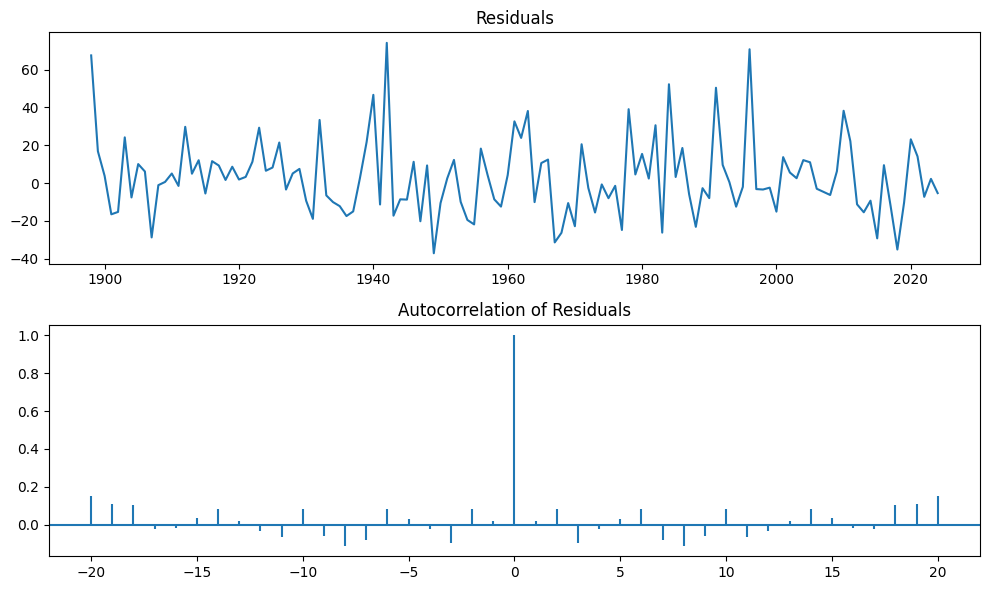

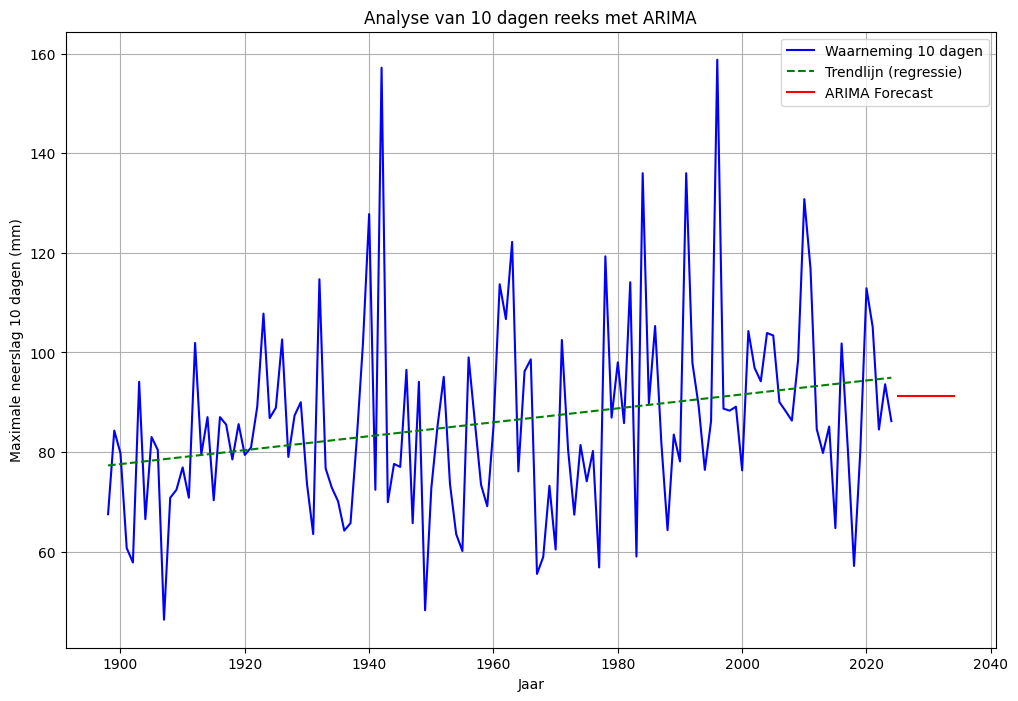

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

# Zoek de verwerkte CSV in een paar waarschijnlijke locaties
csv_candidates = [
    Path('../data/processed_max_neerslag.csv'),
    Path('data/processed_max_neerslag.csv'),
    Path('../../data/processed_max_neerslag.csv'),
]
csv_path = next((p for p in csv_candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError('Kon het verwerkte CSV-bestand niet vinden. Voer eerst de data-inleesstap uit of controleer het pad.')
print(f'Reading processed CSV from: {csv_path.resolve()}')

data_dir = csv_path.parent

df = pd.read_csv(csv_path, index_col='Jaar')

# Select the 10 dagen time series
ts = df['Waarneming 10 dagen'].dropna()

print("Time Series: Waarneming 10 dagen")
print(f"Length: {len(ts)}")
print(f"Mean: {ts.mean():.2f}")
print(f"Std: {ts.std():.2f}")

# Check stationarity with ADF test
adf_result = adfuller(ts)
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print("Stationary" if adf_result[1] < 0.05 else "Non-stationary")

# Ljung-Box test for autocorrelation
lb_test = acorr_ljungbox(ts, lags=10)
print("Ljung-Box test for autocorrelation:")
print(lb_test)

# Fit auto ARIMA
print("\nFitting ARIMA...")
model = auto_arima(ts, seasonal=False, trace=True, error_action='ignore', suppress_warnings=True)
print(model.summary())

# Fit the model
model_fit = ARIMA(ts, order=model.order).fit()

# Residuals analysis
residuals = model_fit.resid
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(residuals)
plt.title('Residuals')
plt.subplot(2, 1, 2)
plt.acorr(residuals, maxlags=20)
plt.title('Autocorrelation of Residuals')
plt.tight_layout()
plt.savefig(data_dir / 'arima_residuals_10dagen.png')
print(f"Residuals plot saved to {data_dir / 'arima_residuals_10dagen.png'}")

# Forecast next 10 years
forecast = model_fit.forecast(steps=10)
print("\nForecast for next 10 years:")
forecast_years = range(int(ts.index[-1]) + 1, int(ts.index[-1]) + 11)
for year, val in zip(forecast_years, forecast):
    print(f"{year}: {val:.2f}")

# Plot the original, trend, and forecast
trend = df['Trendlijn 10 dagen'].dropna()
plt.figure(figsize=(12, 8))
plt.plot(ts.index, ts, label='Waarneming 10 dagen', color='blue')
plt.plot(trend.index, trend, label='Trendlijn (regressie)', color='green', linestyle='--')
plt.plot(forecast_years, forecast, label='ARIMA Forecast', color='red')
plt.xlabel('Jaar')
plt.ylabel('Maximale neerslag 10 dagen (mm)')
plt.title('Analyse van 10 dagen reeks met ARIMA')
plt.legend()
plt.grid(True)
plt.savefig(data_dir / 'analysis_10dagen.png')
print(f"Analysis plot saved to {data_dir / 'analysis_10dagen.png'}")

Belangrijke bevindingen:

Reeks is stationair na differencing (ADF test p<0.001).
Weinig autocorrelatie in de originele reeks (Ljung-Box tests niet significant).
Beste ARIMA model: (0,1,1) - random walk met drift (geen duidelijke trend na differencing).
Residuals tonen geen autocorrelatie (goed model).
Forecast voor volgende 10 jaar: constant ~91.2 mm (geen trend).
De regressie in de XLS (trendlijn) toont een lineaire trend, maar ARIMA vindt geen significante trend na accounting voor autocorrelatie. Het model is conservatiever.

## Waarom gewone regressie niet toegestaan is voor tijdsreeksen

Gewone lineaire regressie (OLS) gaat uit van de Gauss-Markov assumpties:
- Geen autocorrelatie in de residuals (error terms zijn onafhankelijk).
- Homooskedasticiteit (constante variantie van errors).
- Geen multicollineariteit.

In tijdsreeksen is autocorrelatie vaak aanwezig: waarden op tijdstip t hangen af van vorige tijdstippen (t-1, t-2, etc.). Dit schendt de onafhankelijkheid assumptie, waardoor OLS schattingen inefficient en biased kunnen zijn. Standaardfouten zijn te laag, leading tot te veel false positives in hypothesis tests.

Voor tijdsreeksen zijn modellen zoals ARIMA nodig, die autocorrelatie expliciet modelleren. Alternatieven: GLS met autocorrelatie-structuur, of HAC (Heteroskedasticity and Autocorrelation Consistent) standaardfouten voor OLS.

In [31]:
import pandas as pd
from pathlib import Path
from statsmodels.tsa.ar_model import AutoReg

# Zoek de verwerkte CSV in een paar waarschijnlijke locaties
csv_candidates = [
    Path('../data/processed_max_neerslag.csv'),
    Path('data/processed_max_neerslag.csv'),
    Path('../../data/processed_max_neerslag.csv'),
]
csv_path = next((p for p in csv_candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError('Kon het verwerkte CSV-bestand niet vinden. Voer eerst de data-inleesstap uit of controleer het pad.')
print(f'Reading processed CSV from: {csv_path.resolve()}')

# Lees de data
df = pd.read_csv(csv_path, index_col='Jaar')
ts = df['Waarneming 10 dagen'].dropna()

# Exog voor trend
years = ts.index.astype(float).values.reshape(-1, 1)

# Fit AutoReg met AR(1) en exog
model = AutoReg(ts, lags=1, exog=years)
fit = model.fit()

# Print summary
print(fit.summary())

Reading processed CSV from: C:\Users\stoopre\OneDrive - Vlaamse overheid - Office 365\Documenten\A_WERK_projecten\extreme_neerrslag\neerslag_vs\data\processed_max_neerslag.csv
                             AutoReg Model Results                             
Dep. Variable:     Waarneming 10 dagen   No. Observations:                  127
Model:                    AutoReg-X(1)   Log Likelihood                -550.427
Method:                Conditional MLE   S.D. of innovations             19.097
Date:                 Mon, 27 Apr 2026   AIC                           1108.855
Time:                         17:26:20   BIC                           1120.200
Sample:                              1   HQIC                          1113.464
                                   127                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
co

## Resultaten voor de volledige 10 dagen reeks

Hieronder worden de modelsummary en een plot van observaties versus fitted values weergegeven. Dit helpt om te zien hoe goed het AR(1) model met trend bij de data past.

                             AutoReg Model Results                             
Dep. Variable:     Waarneming 10 dagen   No. Observations:                  127
Model:                    AutoReg-X(1)   Log Likelihood                -550.427
Method:                Conditional MLE   S.D. of innovations             19.097
Date:                 Mon, 27 Apr 2026   AIC                           1108.855
Time:                         17:26:20   BIC                           1120.200
Sample:                              1   HQIC                          1113.464
                                   127                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   -181.3294     93.390     -1.942      0.052    -364.370       1.712
Waarneming 10 dagen.L1    -0.0029      0.089     -0.033      0.974      -0.177       0.

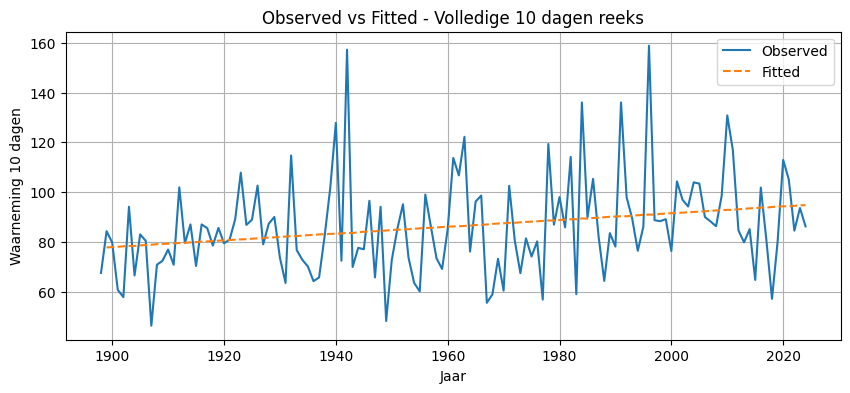

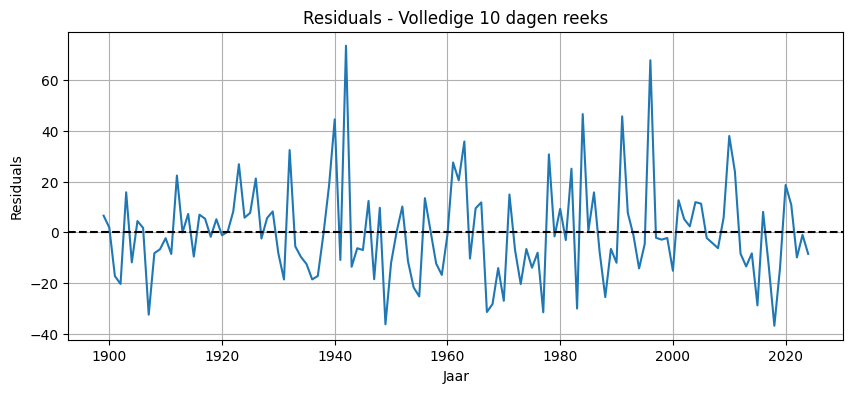

In [32]:
import matplotlib.pyplot as plt

print(fit.summary())

plt.figure(figsize=(10, 4))
plt.plot(ts.index, ts, label='Observed')
plt.plot(fit.fittedvalues.index, fit.fittedvalues, label='Fitted', linestyle='--')
plt.xlabel('Jaar')
plt.ylabel('Waarneming 10 dagen')
plt.title('Observed vs Fitted - Volledige 10 dagen reeks')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(fit.resid.index, fit.resid)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('Jaar')
plt.ylabel('Residuals')
plt.title('Residuals - Volledige 10 dagen reeks')
plt.grid(True)
plt.show()

In [33]:
# Analyse voor de laatste 30 jaar
import pandas as pd
from pathlib import Path
from statsmodels.tsa.ar_model import AutoReg

# Maak deze cel onafhankelijk van eerdere cellen.
if 'ts' not in globals():
    csv_candidates = [
        Path('../data/processed_max_neerslag.csv'),
        Path('data/processed_max_neerslag.csv'),
        Path('../../data/processed_max_neerslag.csv'),
    ]
    csv_path = next((p for p in csv_candidates if p.exists()), None)
    if csv_path is None:
        raise FileNotFoundError('Kon het verwerkte CSV-bestand niet vinden. Voer eerst de data-inleesstap uit of controleer het pad.')
    df = pd.read_csv(csv_path, index_col='Jaar')
    ts = df['Waarneming 10 dagen'].dropna()

ts_last30 = ts.tail(30)
years_last30 = ts_last30.index.astype(float).values.reshape(-1, 1)

model_last30 = AutoReg(ts_last30, lags=1, exog=years_last30)
fit_last30 = model_last30.fit()

print('AutoReg(1) met trend voor laatste 30 jaar:')
print(fit_last30.summary())


AutoReg(1) met trend voor laatste 30 jaar:
                             AutoReg Model Results                             
Dep. Variable:     Waarneming 10 dagen   No. Observations:                   30
Model:                    AutoReg-X(1)   Log Likelihood                -125.403
Method:                Conditional MLE   S.D. of innovations             18.271
Date:                 Mon, 27 Apr 2026   AIC                            258.806
Time:                         17:26:20   BIC                            264.275
Sample:                              1   HQIC                           260.519
                                    30                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   1363.5249    843.085      1.617      0.106    -288.891    3015.941
Waarneming 10 dagen.L1     0.0357      0.183

## Resultaten voor de laatste 30 jaar

Hieronder worden de modelsummary en een plot van observaties versus fitted values weergegeven voor de meest recente 30 jaar.

                             AutoReg Model Results                             
Dep. Variable:     Waarneming 10 dagen   No. Observations:                   30
Model:                    AutoReg-X(1)   Log Likelihood                -125.403
Method:                Conditional MLE   S.D. of innovations             18.271
Date:                 Mon, 27 Apr 2026   AIC                            258.806
Time:                         17:26:20   BIC                            264.275
Sample:                              1   HQIC                           260.519
                                    30                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   1363.5249    843.085      1.617      0.106    -288.891    3015.941
Waarneming 10 dagen.L1     0.0357      0.183      0.195      0.845      -0.323       0.

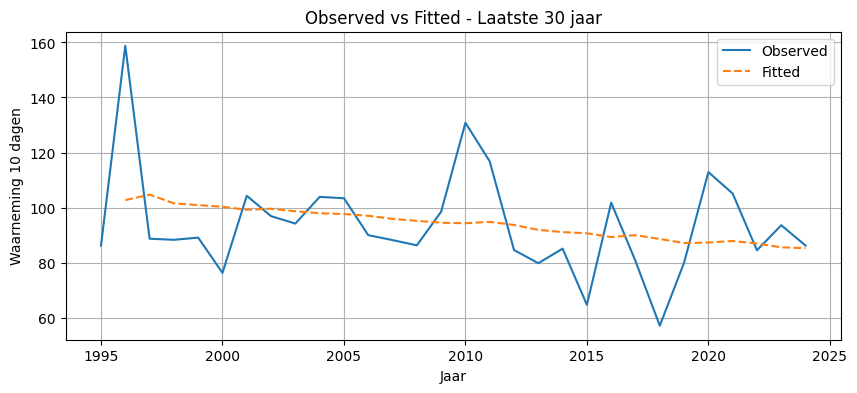

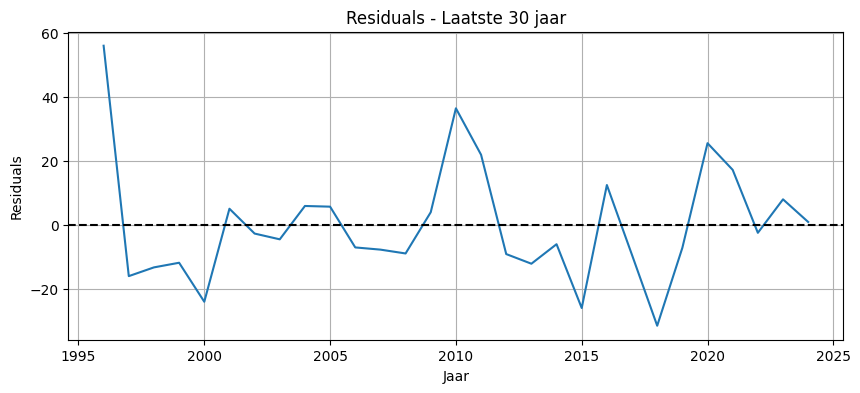

In [34]:
# Plot laatste 30 jaar - zelfstandige versie
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.ar_model import AutoReg

# Deze cel kan los uitgevoerd worden. Als fit_last30 nog niet bestaat,
# wordt het model hier opnieuw opgebouwd.
if 'fit_last30' not in globals() or 'ts_last30' not in globals():
    csv_candidates = [
        Path('../data/processed_max_neerslag.csv'),
        Path('data/processed_max_neerslag.csv'),
        Path('../../data/processed_max_neerslag.csv'),
    ]
    csv_path = next((p for p in csv_candidates if p.exists()), None)
    if csv_path is None:
        raise FileNotFoundError('Kon het verwerkte CSV-bestand niet vinden. Voer eerst de data-inleesstap uit of controleer het pad.')

    df = pd.read_csv(csv_path, index_col='Jaar')
    ts = df['Waarneming 10 dagen'].dropna()
    ts_last30 = ts.tail(30)
    years_last30 = ts_last30.index.astype(float).values.reshape(-1, 1)
    model_last30 = AutoReg(ts_last30, lags=1, exog=years_last30)
    fit_last30 = model_last30.fit()

print(fit_last30.summary())

# AutoReg(lags=1) levert fitted values en residuals vanaf het tweede jaar.
fitted_last30 = pd.Series(np.asarray(fit_last30.fittedvalues), index=ts_last30.index[1:], name='Fitted')
resid_last30 = pd.Series(np.asarray(fit_last30.resid), index=ts_last30.index[1:], name='Residuals')

plt.figure(figsize=(10, 4))
plt.plot(ts_last30.index, ts_last30, label='Observed')
plt.plot(fitted_last30.index, fitted_last30, label='Fitted', linestyle='--')
plt.xlabel('Jaar')
plt.ylabel('Waarneming 10 dagen')
plt.title('Observed vs Fitted - Laatste 30 jaar')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(resid_last30.index, resid_last30)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('Jaar')
plt.ylabel('Residuals')
plt.title('Residuals - Laatste 30 jaar')
plt.grid(True)
plt.show()


## Uitleg voor de laatste 30 jaar

Deze regressie is hetzelfde model maar aangebracht op de meest recente 30 waarden van de 10 dagen reeks.

- Hiermee test je of de trend en AR(1) parameter ook in de recente periode hetzelfde blijven.
- Verwacht mogelijk grotere onzekerheid door een kleinere steekproef.
- De AR(1) term geeft aan of er autocorrelatie in de meest recente 30 jaar aanwezig is.

Voer de code uit om de coëfficiënten en significantie voor deze subset te bekijken.

## Uitleg van de AutoReg(1) Regressie Coëfficiënten

- **const (-181.33)**: Intercept, niet significant (p=0.052).
- **Waarneming 10 dagen.L1 (-0.003)**: AR(1) coëfficiënt, zeer klein (p=0.974), dus minimale autocorrelatie.
- **x1 (0.136)**: Trend coëfficiënt (per jaar), significant (p=0.005), ~0.14 mm stijging per jaar.

Dit is een regressie met geschatte AR(1) parameter, zonder ARIMA differencing. De AR term is effectief 0, dus lijkt op OLS met trend.

In dit KMI-klimaatrapport wordt voor de waargenomen tijdreeksen eigenlijk een vrij duidelijke tweesporenmethode gebruikt:

1. Eerst: lange, gehomogeniseerde tijdreeksen

Vooraleer trends worden berekend, benadrukt het KMI dat je alleen zinvol klimaatverandering kunt analyseren met kwaliteitsvolle, voldoende lange en zo homogeen mogelijke tijdreeksen. Ze corrigeren dus eerst voor niet-klimatologische breuken zoals verhuis van meetstation, wijziging van instrumenten, meetomgeving, waarnemingsprocedures, enz. Dat noemen ze homogenisatie. Zonder die stap kan je een kunstmatige trend meten die eigenlijk door meetomstandigheden komt, niet door klimaatverandering.

Dat is methodologisch belangrijk: het KMI zegt dus niet “neem gewoon alle ruwe jaarlijkse waarden en trek er een regressielijn door”. Eerst moeten de meetreeksen klimaatkundig betrouwbaar gemaakt worden.

2. Voor de grafieken gebruiken ze systematisch twee technieken

Het meest expliciet staat dit in het kader “Bepaling van klimatologische trends in de waarnemingen” rond pagina 7 van het rapport. Daar staat dat ze in de grafieken systematisch twee technieken toepassen:

A. LOESS / lokale regressie als gladde trendcurve

Voor de volledige lange periode gebruiken ze een spline-kromme op de jaarlijkse waarden. Die neemt de interjaarlijkse variabiliteit weg en geeft een kwalitatief beeld van de meestal niet-lineaire trend over de hele periode. Het rapport zegt expliciet dat deze curve wordt geschat met een lokale regressiemethode: LOESS.

Dit is dus de aanbevolen methode om de vorm van de klimaatevolutie te bekijken: niet forceren dat de trend over 1833–2019 één rechte lijn is, maar toelaten dat er periodes zijn met stabiliteit, versnelling, afvlakking, enz.

Voor temperatuur zie je dat ook inhoudelijk: de gemiddelde temperatuur bleef relatief stabiel in twee grote periodes, ongeveer 1833–1910 en 1911–1985, waarna vanaf 1986 duidelijk hogere waarden optreden. Een globale lineaire trend over heel 1833–2019 zou die structuur verdoezelen.

B. Lineaire regressie vanaf 1981 om de recente trend te kwantificeren

Daarnaast passen ze een regressielijn op de jaarlijkse waarden sinds 1981 toe. Die dient om de recente lineaire trend te kwantificeren, bijvoorbeeld in °C per decennium, mm per decennium, dagen per decennium of % per decennium. De helling wordt alleen in de legende vermeld wanneer ze statistisch significant is.

Bijvoorbeeld voor de jaargemiddelde temperatuur in Brussel-Ukkel rapporteren ze sinds 1981 een significante opwarming van +0,38°C per decennium. Voor de seizoenen rapporteren ze eveneens significante trends: winter +0,45°C, lente +0,39°C, zomer +0,40°C en herfst +0,31°C per decennium.

3. Wat bedoelen ze met “significant”?

In dit rapport is “significant” niet altijd exact hetzelfde criterium. Voor de Ukkel-grafieken zeggen ze dat een trend significant is wanneer de geschatte helling met minstens 90% waarschijnlijkheid aan een werkelijke trend in de waarnemingen kan worden toegeschreven.

Voor de ruimtelijke analyse over België, bijvoorbeeld temperatuurtrends 1954–2019, spreken ze over trends die statistisch verschillend zijn van nul op het 95%-significantieniveau. De kaarten tonen stations met een zwarte stip wanneer de trend significant is.

Dus: voor Ukkel gebruikt het rapport vaak een 90%-criterium; voor de ruimtelijke kaarten eerder 95%.

4. Welke methode is dus “aanbevolen” om te bepalen of het klimaat wijzigt?

Kort gezegd:

Voor detectie en beschrijving van klimaatverandering over lange tijd:

gebruik gehomogeniseerde lange tijdreeksen + LOESS/lokale regressie om de niet-lineaire evolutie zichtbaar te maken.

Voor kwantificering van recente klimaatverandering:

gebruik lineaire regressie vanaf een recente referentieperiode, hier meestal sinds 1981, en rapporteer de helling per decennium met significantietoets.

Dat is de kern.

5. Belangrijke nuance: dit is niet gewoon “OLS over de volledige eeuw”

Dit is net de methodologische les die je eruit kunt halen. Het KMI gebruikt geen eenvoudige globale lineaire regressie over de volledige beschikbare periode als hoofdboodschap voor klimaatverandering. Voor de lange periode gebruiken ze LOESS om de niet-lineaire trend te tonen. De lineaire regressie wordt beperkt tot de recente periode sinds 1981 om de huidige trend te kwantificeren.

Dat is methodologisch verdedigbaar, omdat klimaatreeksen vaak niet-stationair zijn en omdat de trend niet constant is over 150 à 200 jaar. Eén rechte lijn over 1833–2019 zou methodologisch te grof zijn.

6. Voor temperatuur is het resultaat zeer duidelijk; voor neerslag veel minder

Voor temperatuur concludeert het KMI ondubbelzinnig dat de seizoens- en jaartemperaturen sinds de 19e eeuw gestegen zijn, met een sterkere tweede opwarming vanaf het einde van de jaren 1980.

Voor neerslag zijn de resultaten minder eenduidig. Het rapport stelt dat neerslag in Ukkel veel minder uitgesproken trends vertoont dan temperatuur, deels door de grote natuurlijke variabiliteit. Jaarlijkse en winterse neerslag vertonen op lange termijn een toenemende trend, maar sinds 1981 is de jaarlijkse neerslagtrend niet significant. Voor sommige extremen, zoals aantal dagen met zware neerslag of maximale uurneerslag, worden wel significante toenames gevonden.

samenvatting

Het KMI beveelt impliciet een combinatie aan van homogenisatie, niet-lineaire trendvisualisatie met LOESS en kwantificering van recente trends met lineaire regressie sinds 1981. LOESS dient om de klimaatevolutie over de volledige periode te beschrijven zonder een constante trend te veronderstellen. De lineaire regressie sinds 1981 dient om de recente verandering in interpreteerbare eenheden per decennium te rapporteren en op significantie te toetsen.

kritisch:

Een simpele OLS-trend over de volledige lange tijdreeks is volgens deze aanpak te simplistisch voor klimaatcommunicatie, omdat die de fasering en versnelling van klimaatverandering kan maskeren. Voor temperatuur is de recente lineaire trend sinds 1981 zeer bruikbaar; voor neerslag moet je veel voorzichtiger zijn wegens grotere variabiliteit en minder consistente significantie.

## Aanvulling: KMI-methode met LOESS en recente trend

Voor deze analyse volgen we de tweesporenmethode uit het KMI-klimaatrapport voor waargenomen klimaatreeksen:

1. **Volledige lange reeks beschrijven met LOESS**  
   De volledige periode wordt niet samengevat met ??n globale rechte lijn. We gebruiken een lokale regressie/LOESS-smoother op de jaarlijkse 10-daagse maxima. Die curve is bedoeld als beschrijvende visualisatie van de langetermijnevolutie en laat niet-lineariteit toe: periodes met stijging, daling, stabiliteit of versnelling kunnen zichtbaar worden.

2. **Recente trend kwantificeren vanaf 1981**  
   De recente verandering wordt apart gekwantificeerd met een lineaire trend vanaf 1981, zoals het KMI vaak doet in de Ukkel-grafieken. De helling wordt uitgedrukt in mm per decennium.

3. **Niet na?ef omgaan met significantie**  
   Een lineaire regressie vanaf 1981 is verdedigbaar als KMI-conforme samenvatting, maar de gewone OLS-p-waarde is niet genoeg als methodische onderbouwing. Daarom rapporteren we hier autocorrelatie-diagnostiek en gebruiken we HAC/Newey-West robuuste standaardfouten voor de recente regressie. Daarnaast tonen we Theil-Sen en Mann-Kendall als robuuste gevoeligheidschecks.

4. **Interpretatie voor extreme neerslag**  
   Deze reeks bestaat uit jaarlijkse maxima van gecumuleerde neerslag over 10 dagen. De LOESS-curve beschrijft de evolutie van de annual maxima over de volledige meetperiode. De trend sinds 1981 zegt alleen iets over de recente lineaire verandering, niet over de volledige historische evolutie en ook niet over terugkeerperioden. Voor terugkeerwaarden blijft een afzonderlijke GEV-analyse nodig.


Aantal jaren: 127
Periode: 1898-2024
Gemiddeld jaarlijks 10-daags maximum: 86.1 mm
Hoogste waarde: 158.8 mm in 1996


,Diagnose,Waarde
0,Aantal jaren sinds 1981,44.0000
1,HAC maxlags,3.0000
2,Lag-1 autocorrelatie residualen,-0.0722
3,Durbin-Watson residualen,2.1360


,Ljung-Box statistic,p-waarde
1,0.2431,0.6220
5,7.8714,0.1635
10,12.9023,0.2292


,Methode,Schatting,Onzekerheid / significantie
0,"Lineaire trend sinds 1981, HAC/Newey-West",-0.147 mm/jaar (-1.47 mm/decennium),90% BI: -4.57 tot 1.62 mm/decennium; 95% BI: -...
1,"Theil-Sen sinds 1981, robuuste helling",-0.065 mm/jaar (-0.65 mm/decennium),90% BI slope: -3.80 tot 2.61 mm/decennium
2,Mann-Kendall sinds 1981,tau = -0.041,p = 0.7007


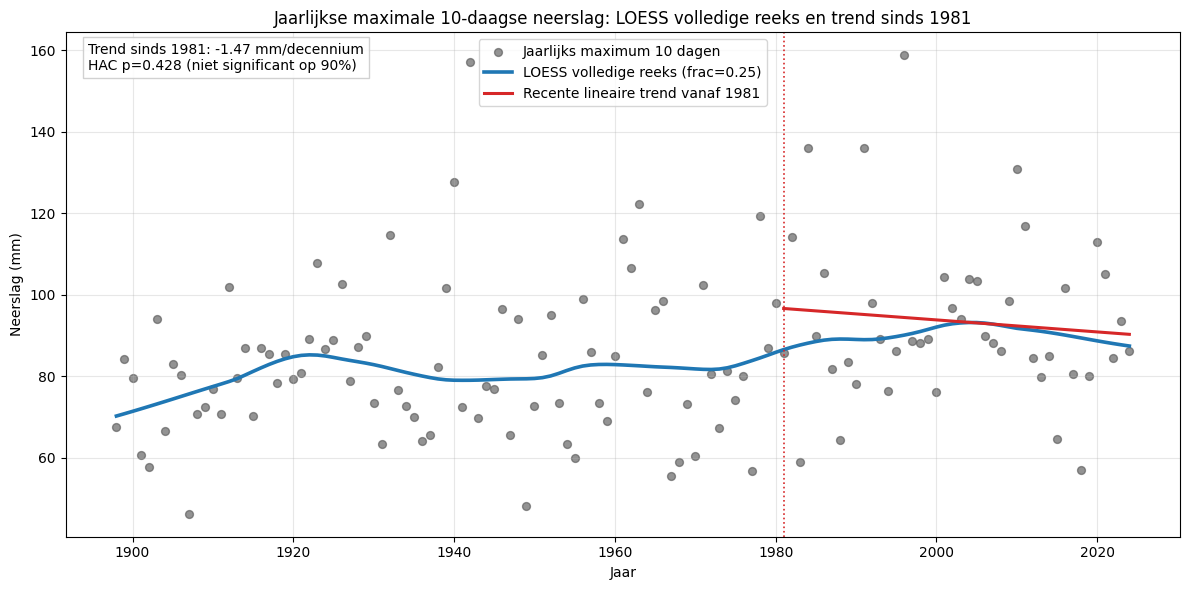

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
try:
    from IPython.display import display
except ImportError:
    display = print

# ------------------------------------------------------------
# 1. Data inlezen: jaarlijkse maxima voor 10-daagse neerslag
# ------------------------------------------------------------
csv_candidates = [
    Path('../data/processed_max_neerslag.csv'),
    Path('data/processed_max_neerslag.csv'),
    Path('../../data/processed_max_neerslag.csv'),
]
csv_path = next((p for p in csv_candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError('Kon processed_max_neerslag.csv niet vinden.')

df = pd.read_csv(csv_path)
extreme = df[['Jaar', 'Waarneming 10 dagen']].dropna().copy()
extreme['Jaar'] = extreme['Jaar'].astype(int)
extreme = extreme.rename(columns={'Waarneming 10 dagen': 'max10d_mm'})
extreme = extreme.sort_values('Jaar')

years = extreme['Jaar'].to_numpy(dtype=float)
x = extreme['max10d_mm'].to_numpy(dtype=float)

print(f'Aantal jaren: {len(extreme)}')
print(f'Periode: {int(years.min())}-{int(years.max())}')
print(f'Gemiddeld jaarlijks 10-daags maximum: {x.mean():.1f} mm')
print(f'Hoogste waarde: {x.max():.1f} mm in {int(years[x.argmax()])}')

# ------------------------------------------------------------
# 2. Volledige reeks: LOESS/lokale regressie
# ------------------------------------------------------------
# frac bepaalt hoe glad de curve is. 0.25 gebruikt ongeveer een kwart van de reeks
# per lokaal venster. Dit is een visualisatiekeuze, geen significantietest.
loess_frac = 0.25
loess_curve = lowess(x, years, frac=loess_frac, it=1, return_sorted=True)

# ------------------------------------------------------------
# 3. Recente trend vanaf 1981: lineair, met robuuste onzekerheid
# ------------------------------------------------------------
start_recent = 1981
recent = extreme[extreme['Jaar'] >= start_recent].copy()
y_recent = recent['Jaar'].to_numpy(dtype=float)
x_recent = recent['max10d_mm'].to_numpy(dtype=float)
t_recent = y_recent - start_recent

X = sm.add_constant(t_recent)
ols_recent = sm.OLS(x_recent, X).fit()

# HAC/Newey-West standaardfouten corrigeren voor autocorrelatie/heteroskedasticiteit.
# De lag-keuze is een gangbare vuistregel en blijft expliciet gerapporteerd.
hac_lags = max(1, int(np.floor(4 * (len(recent) / 100) ** (2 / 9))))
hac_recent = ols_recent.get_robustcov_results(cov_type='HAC', maxlags=hac_lags)

slope_year = hac_recent.params[1]
slope_decade = slope_year * 10
ci90 = hac_recent.conf_int(alpha=0.10)[1]
ci95 = hac_recent.conf_int(alpha=0.05)[1]
p_hac = hac_recent.pvalues[1]

# Autocorrelatie-diagnostiek op residualen van de recente regressie
resid = ols_recent.resid
lag1_resid = pd.Series(resid).autocorr(lag=1)
dw_resid = durbin_watson(resid)
lb_resid = acorr_ljungbox(resid, lags=[1, 5, 10], return_df=True)

recent_diag = pd.DataFrame({
    'Diagnose': ['Aantal jaren sinds 1981', 'HAC maxlags', 'Lag-1 autocorrelatie residualen', 'Durbin-Watson residualen'],
    'Waarde': [len(recent), hac_lags, lag1_resid, dw_resid],
})
display(recent_diag.round(4))
display(lb_resid.rename(columns={'lb_stat': 'Ljung-Box statistic', 'lb_pvalue': 'p-waarde'}).round(4))

# Robuuste gevoeligheidschecks voor de recente periode
sen_recent = stats.theilslopes(x_recent, y_recent, alpha=0.90)

def mann_kendall_test(values):
    values = np.asarray(values, dtype=float)
    n = len(values)
    s = 0.0
    for k in range(n - 1):
        s += np.sign(values[k + 1:] - values[k]).sum()

    _, counts = np.unique(values, return_counts=True)
    tie_term = np.sum(counts * (counts - 1) * (2 * counts + 5))
    var_s = (n * (n - 1) * (2 * n + 5) - tie_term) / 18

    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s < 0:
        z = (s + 1) / np.sqrt(var_s)
    else:
        z = 0.0

    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    kendall_tau = s / (0.5 * n * (n - 1))
    return pd.Series({'S': s, 'z': z, 'p_waarde': p_value, 'Kendall_tau': kendall_tau})

mk_recent = mann_kendall_test(x_recent)

trend_results = pd.DataFrame({
    'Methode': [
        'Lineaire trend sinds 1981, HAC/Newey-West',
        'Theil-Sen sinds 1981, robuuste helling',
        'Mann-Kendall sinds 1981',
    ],
    'Schatting': [
        f'{slope_year:.3f} mm/jaar ({slope_decade:.2f} mm/decennium)',
        f'{sen_recent.slope:.3f} mm/jaar ({sen_recent.slope * 10:.2f} mm/decennium)',
        f"tau = {mk_recent['Kendall_tau']:.3f}",
    ],
    'Onzekerheid / significantie': [
        f'90% BI: {ci90[0] * 10:.2f} tot {ci90[1] * 10:.2f} mm/decennium; 95% BI: {ci95[0] * 10:.2f} tot {ci95[1] * 10:.2f}; p = {p_hac:.4f}',
        f'90% BI slope: {sen_recent.low_slope * 10:.2f} tot {sen_recent.high_slope * 10:.2f} mm/decennium',
        f"p = {mk_recent['p_waarde']:.4f}",
    ],
})
display(trend_results)

# ------------------------------------------------------------
# 4. Visualisatie volgens KMI-logica
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(years, x, color='0.35', alpha=0.65, s=32, label='Jaarlijks maximum 10 dagen')
ax.plot(loess_curve[:, 0], loess_curve[:, 1], color='tab:blue', linewidth=2.6, label=f'LOESS volledige reeks (frac={loess_frac})')

recent_fit = hac_recent.params[0] + hac_recent.params[1] * t_recent
ax.plot(y_recent, recent_fit, color='tab:red', linewidth=2.2, label=f'Recente lineaire trend vanaf {start_recent}')
ax.axvline(start_recent, color='tab:red', linestyle=':', linewidth=1.2)

sig90 = p_hac < 0.10
sig95 = p_hac < 0.05
significance_label = 'significant op 95%' if sig95 else ('significant op 90%' if sig90 else 'niet significant op 90%')

ax.set_title('Jaarlijkse maximale 10-daagse neerslag: LOESS volledige reeks en trend sinds 1981')
ax.set_xlabel('Jaar')
ax.set_ylabel('Neerslag (mm)')
ax.text(
    0.02, 0.98,
    f'Trend sinds {start_recent}: {slope_decade:.2f} mm/decennium\nHAC p={p_hac:.3f} ({significance_label})',
    transform=ax.transAxes,
    va='top',
    ha='left',
    bbox=dict(facecolor='white', edgecolor='0.8', alpha=0.9),
)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Eerste resultaten met LOESS + recente trend

Met deze KMI-conforme aanpak verschuift de conclusie:

- De volledige periode **1898-2024** wordt beschreven met LOESS. Die curve is bedoeld om de vorm van de langetermijnevolutie te tonen, niet om ??n globale lineaire trend te bewijzen.
- Voor de recente periode **1981-2024** is de lineaire trend ongeveer **-1,47 mm per decennium**.
- Met HAC/Newey-West robuuste onzekerheid is die recente trend **niet significant**: p ? **0,43**. Ook het 90%-betrouwbaarheidsinterval bevat nul.
- De robuuste checks bevestigen dat beeld: Theil-Sen geeft ongeveer **-0,65 mm per decennium**, en Mann-Kendall sinds 1981 geeft p ? **0,70**.
- De residualen van de recente regressie tonen in deze reeks geen duidelijke autocorrelatie, maar dat is nu expliciet gecontroleerd in plaats van aangenomen.

Interpretatie: voor deze 10-daagse jaarlijkse maxima kan je de volledige reeks het best tonen met LOESS, maar de recente KMI-achtige trend sinds 1981 is op basis van de huidige data **niet significant stijgend**. Dat is voor neerslag plausibel: de natuurlijke variabiliteit is groot en recente trends zijn minder eenduidig dan bij temperatuur.


## Test op level shift vanaf 1981

Hier testen we of de jaarlijkse 10-daagse neerslagmaxima vanaf 1981 op een ander niveau liggen dan ervoor. Omdat 1981 vooraf gekozen is op basis van de KMI-methodiek, behandelen we dit als een **bekende interventiedatum** en niet als een vrij gezochte changepoint.

De meest verdedigbare test is een regressiemodel met een **step-dummy vanaf 1981**, met HAC/Newey-West robuuste standaardfouten. Dat test een abrupte niveauverschuiving terwijl autocorrelatie en heteroskedasticiteit in de onzekerheid worden meegenomen.

Daarnaast tonen we drie gevoeligheidschecks:

- een eenvoudige pre/post level shift zonder trendcorrectie;
- een model met gemeenschappelijke langetermijntrend plus level shift;
- verdelingsvrije tests zoals permutation, Mann-Whitney en Brunner-Munzel;
- indicatief een GEV-vergelijking voor annual maxima voor en na 1981.

Interpretatie: de eenvoudige pre/post vergelijking beantwoordt ?ligt de periode na 1981 gemiddeld hoger??. Het model met trendcorrectie beantwoordt strenger ?is er bovenop de langetermijntrend een abrupte sprong vanaf 1981??.


In [36]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
from IPython.display import display

# ------------------------------------------------------------
# Data
# ------------------------------------------------------------
csv_candidates = [
    Path('../data/processed_max_neerslag.csv'),
    Path('data/processed_max_neerslag.csv'),
    Path('../../data/processed_max_neerslag.csv'),
]
csv_path = next((p for p in csv_candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError('Kon processed_max_neerslag.csv niet vinden.')

df = pd.read_csv(csv_path)
level = df[['Jaar', 'Waarneming 10 dagen']].dropna().copy()
level['Jaar'] = level['Jaar'].astype(int)
level = level.rename(columns={'Waarneming 10 dagen': 'max10d_mm'}).sort_values('Jaar')
level['post1981'] = (level['Jaar'] >= 1981).astype(int)
level['t_center'] = level['Jaar'] - 1981
level['post_t'] = level['post1981'] * level['t_center']

pre = level.loc[level['Jaar'] < 1981, 'max10d_mm'].to_numpy(dtype=float)
post = level.loc[level['Jaar'] >= 1981, 'max10d_mm'].to_numpy(dtype=float)

summary = pd.DataFrame({
    'Periode': ['voor 1981', 'vanaf 1981', 'verschil post-pre'],
    'n': [len(pre), len(post), ''],
    'gemiddelde_mm': [pre.mean(), post.mean(), post.mean() - pre.mean()],
    'mediaan_mm': [np.median(pre), np.median(post), np.median(post) - np.median(pre)],
    'sd_mm': [pre.std(ddof=1), post.std(ddof=1), ''],
})
display(summary.round(2))

# ------------------------------------------------------------
# Hulpfuncties
# ------------------------------------------------------------
def permutation_test(values_a, values_b, statistic='mean', n_perm=20000, seed=123):
    rng = np.random.default_rng(seed)
    values_a = np.asarray(values_a, dtype=float)
    values_b = np.asarray(values_b, dtype=float)
    observed = (values_b.mean() - values_a.mean()) if statistic == 'mean' else (np.median(values_b) - np.median(values_a))
    pooled = np.concatenate([values_a, values_b])
    n_b = len(values_b)
    count = 0
    for _ in range(n_perm):
        perm = rng.permutation(pooled)
        perm_b = perm[:n_b]
        perm_a = perm[n_b:]
        diff = (perm_b.mean() - perm_a.mean()) if statistic == 'mean' else (np.median(perm_b) - np.median(perm_a))
        count += abs(diff) >= abs(observed)
    return observed, (count + 1) / (n_perm + 1)

def fit_hac_model(formula_cols, label):
    X = sm.add_constant(level[formula_cols])
    model = sm.OLS(level['max10d_mm'], X).fit()
    hac_lags = max(1, int(np.floor(4 * (len(level) / 100) ** (2 / 9))))
    robust = model.get_robustcov_results(cov_type='HAC', maxlags=hac_lags)
    names = robust.model.exog_names
    rows = []
    for name, param, pvalue, ci in zip(names, robust.params, robust.pvalues, robust.conf_int(alpha=0.05)):
        rows.append({
            'model': label,
            'parameter': name,
            'schatting': param,
            'ci95_laag': ci[0],
            'ci95_hoog': ci[1],
            'p_waarde': pvalue,
            'hac_lags': hac_lags,
        })
    diagnostics = {
        'model': label,
        'durbin_watson': durbin_watson(model.resid),
        'ljung_box_p_lag1': acorr_ljungbox(model.resid, lags=[1], return_df=True)['lb_pvalue'].iloc[0],
        'ljung_box_p_lag5': acorr_ljungbox(model.resid, lags=[5], return_df=True)['lb_pvalue'].iloc[0],
    }
    return pd.DataFrame(rows), diagnostics

# ------------------------------------------------------------
# 1. Level-shift/interventiemodellen met HAC-onzekerheid
# ------------------------------------------------------------
models = []
diags = []
for cols, label in [
    (['post1981'], 'step only: post1981'),
    (['t_center', 'post1981'], 'gemeenschappelijke trend + step'),
    (['t_center', 'post1981', 'post_t'], 'piecewise trend + step'),
]:
    table, diag = fit_hac_model(cols, label)
    models.append(table)
    diags.append(diag)

model_results = pd.concat(models, ignore_index=True)
# Druk step-effecten ook uit als mm verschil. Trends staan in mm/jaar.
display(model_results.round(4))
display(pd.DataFrame(diags).round(4))

# ------------------------------------------------------------
# 2. Verdelingsvrije gevoeligheidschecks
# ------------------------------------------------------------
perm_mean_diff, perm_mean_p = permutation_test(pre, post, statistic='mean')
perm_median_diff, perm_median_p = permutation_test(pre, post, statistic='median')
welch = stats.ttest_ind(post, pre, equal_var=False)
mann_whitney = stats.mannwhitneyu(post, pre, alternative='two-sided')
brunner_munzel = stats.brunnermunzel(post, pre, alternative='two-sided')

nonparametric = pd.DataFrame({
    'test': [
        'Permutation verschil gemiddelde',
        'Permutation verschil mediaan',
        'Welch t-test gemiddelde',
        'Mann-Whitney verdelingsshift',
        'Brunner-Munzel verdelingsshift',
    ],
    'effect': [
        perm_mean_diff,
        perm_median_diff,
        post.mean() - pre.mean(),
        np.nan,
        np.nan,
    ],
    'p_waarde': [
        perm_mean_p,
        perm_median_p,
        welch.pvalue,
        mann_whitney.pvalue,
        brunner_munzel.pvalue,
    ],
})
display(nonparametric.round(4))

# ------------------------------------------------------------
# 3. Indicatieve GEV-gevoeligheidscheck voor annual maxima
# ------------------------------------------------------------
# Vergelijk een gepoold GEV-model met aparte GEV-modellen voor pre/post.
# Dit is indicatief: bij kleine groepen zijn GEV-parameters onzeker.
pooled = np.concatenate([pre, post])
c_all, loc_all, scale_all = stats.genextreme.fit(pooled)
ll_all = np.sum(stats.genextreme.logpdf(pooled, c_all, loc=loc_all, scale=scale_all))

c_pre, loc_pre, scale_pre = stats.genextreme.fit(pre)
c_post, loc_post, scale_post = stats.genextreme.fit(post)
ll_sep = (
    np.sum(stats.genextreme.logpdf(pre, c_pre, loc=loc_pre, scale=scale_pre))
    + np.sum(stats.genextreme.logpdf(post, c_post, loc=loc_post, scale=scale_post))
)

lr_gev = 2 * (ll_sep - ll_all)
p_gev = 1 - stats.chi2.cdf(lr_gev, df=3)
gev_check = pd.DataFrame({
    'model': ['GEV gepoold', 'GEV voor 1981', 'GEV vanaf 1981', 'LR apart vs gepoold'],
    'locatie': [loc_all, loc_pre, loc_post, np.nan],
    'schaal': [scale_all, scale_pre, scale_post, np.nan],
    'vorm_c': [c_all, c_pre, c_post, np.nan],
    'LR': [np.nan, np.nan, np.nan, lr_gev],
    'p_waarde': [np.nan, np.nan, np.nan, p_gev],
})
display(gev_check.round(4))


,Periode,n,gemiddelde_mm,mediaan_mm,sd_mm
0,voor 1981,83,82.19,79.73,18.476397
1,vanaf 1981,44,93.50,88.90,20.298049
2,verschil post-pre,,11.31,9.17,


,model,parameter,schatting,ci95_laag,ci95_hoog,p_waarde,hac_lags
0,step only: post1981,const,82.1882,77.7589,86.6175,0.0000,4
1,step only: post1981,post1981,11.3143,4.9895,17.6391,0.0006,4
2,gemeenschappelijke trend + step,const,84.6539,76.3028,93.0050,0.0000,4
3,gemeenschappelijke trend + step,t_center,0.0587,-0.0898,0.2072,0.4355,4
4,gemeenschappelijke trend + step,post1981,7.5863,-4.1011,19.2737,0.2013,4
5,piecewise trend + step,const,85.9436,76.9439,94.9432,0.0000,4
6,piecewise trend + step,t_center,0.0894,-0.0706,0.2494,0.2707,4
7,piecewise trend + step,post1981,10.7297,-0.9894,22.4487,0.0724,4
8,piecewise trend + step,post_t,-0.2369,-0.6004,0.1266,0.1995,4


,model,durbin_watson,ljung_box_p_lag1,ljung_box_p_lag5
0,step only: post1981,2.0260,0.8557,0.7591
1,gemeenschappelijke trend + step,2.0308,0.8384,0.7729
2,piecewise trend + step,2.0494,0.7647,0.7172


,test,effect,p_waarde
0,Permutation verschil gemiddelde,11.3143,0.0023
1,Permutation verschil mediaan,9.1700,0.0017
2,Welch t-test gemiddelde,11.3143,0.0028
3,Mann-Whitney verdelingsshift,NaN,0.0006
4,Brunner-Munzel verdelingsshift,NaN,0.0003


,model,locatie,schaal,vorm_c,LR,p_waarde
0,GEV gepoold,77.5887,16.3634,0.0546,NaN,NaN
1,GEV voor 1981,74.2448,15.1697,0.0500,NaN,NaN
2,GEV vanaf 1981,84.9257,16.7287,0.0625,NaN,NaN
3,LR apart vs gepoold,NaN,NaN,NaN,10.8058,0.0128


### Interpretatie level-shift test

De eenvoudige pre/post vergelijking toont een hoger niveau vanaf 1981: het gemiddelde ligt ongeveer **+11,3 mm** hoger en de mediaan ongeveer **+9,2 mm** hoger. Verdelingsvrije tests en permutation tests geven hiervoor kleine p-waarden.

Maar de strengere vraag is of er een **abrupte sprong vanaf 1981 bovenop de langetermijntrend** is. In het model met gemeenschappelijke trend plus step-dummy is het step-effect ongeveer **+7,6 mm**, maar **niet significant** met HAC/Newey-West onzekerheid. In het piecewise model ligt het step-effect rond **+10,7 mm** en is het hoogstens zwak/90%-achtig, niet 95%-robuust.

Kort: er is duidelijk een hoger pre/post niveau na 1981, maar het bewijs voor een zuivere abrupte level shift in 1981, los van langzame evolutie/trend, is veel minder sterk. Voor klimaatinterpretatie is dat onderscheid belangrijk.
